---
**Curso:** DES504 — Inferencia Causal Aplicada con Python (UNI 2026)

**Profesor:** Dr. Jaime Lincovil

**Notebook:** 6 / 32 — Bloque I

**Nivel GCE:** 1 (Localización)

**Dataset:** `syn_late_types`

**Versión:** 2.1 (GCE v2.0 corregida - jerarquía matemática verificada)

**Fecha:** 2026-07-25

---

*Filosofía Proofs-to-Python: todo teorema se ejecuta. Regla 1+1+1: demostración + intuición + código.*


# Capítulo 6: LATE y la Taxonomía de los Respondientes

**Curso:** DES504 — Inferencia Causal Aplicada con Python (UNI 2026)
**Notebook:** 6 / 32 — Bloque I

---

## 1. Marco Teórico

### 1.1 Heterogeneidad del efecto causal

El ATE asume efectos homogéneos. En realidad, el tratamiento puede ayudar a algunos y perjudicar a otros. El **marco de Imbens-Angrist (1994)** formaliza esto identificando el LATE solo para los **compliers**.

### 1.2 La taxonomía de los cuatro tipos

Con instrumento binario $Z$ y tratamiento binario $D$, cada unidad pertenece a uno de 4 tipos:

| Tipo | $D(Z=0)$ | $D(Z=1)$ | Comportamiento |
|------|----------|----------|----------------|
| **Always-takers** | 1 | 1 | Tomarán tratamiento sin importar $Z$ |
| **Never-takers** | 0 | 0 | No tomarán tratamiento sin importar $Z$ |
| **Compliers** | 0 | 1 | Tomarán tratamiento solo si $Z=1$ |
| **Defiers** | 1 | 0 | Tomarán tratamiento solo si $Z=0$ |

### 1.3 Supuesto de monotonía

Para identificar LATE necesitamos **monotonía**: no hay defiers. $P(D(1) \geq D(0)) = 1$, es decir, $Z$ empuja a todos en la misma dirección.

### 1.4 Teorema LATE (Imbens & Angrist 1994)

Bajo (1) independencia $Z \perp (Y(0), Y(1), D(0), D(1))$, (2) relevancia, (3) monotonía:

$$\text{LATE} = \mathbb{E}[Y(1) - Y(0) | \text{complier}] = \frac{\text{ITT}}{P(\text{complier})}$$

### 1.5 Implicaciones y validez externa

- **LATE ≠ ATE en general.** El LATE aplica solo a compliers, no a toda la población.
- **LATE es local:** depende del instrumento específico. Distintos IVs identifican distintos LATEs.
- **Validez externa limitada:** los compliers pueden no representar a la población objetivo de una política.

### 1.6 Dataset: `syn_iv_noncompliance` (sintético)

Diseñado específicamente para ilustrar LATE:
- `z_encouragement`: instrumento binario (estímulo al tratamiento)
- `d_treated`: tratamiento efectivo (con no cumplimiento)
- `y_outcome`: outcome
- `truth_instructor_only.csv` contiene:
  - `compliance_type_truth`: always/never/complier/defier
  - `u_unobserved_truth`: confusor oculto
  - `true_tau = 2.0`: LATE verdadero para compliers


In [1]:
# === 1. Cargar dataset ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings
np.random.seed(42)  # Reproducibilidad
warnings.filterwarnings('ignore')

# --- Local path bootstrap (auto) ---
from pathlib import Path as _Path
import os as _os

def _resolve_data_dir() -> str:
    """Resuelve la carpeta de datos tanto si el CWD es el root del book
    como si es content/bloque_XX (Jupyter) o si se ejecuta vía papermill."""
    env = _os.environ.get("CAUSAL_BOOK_DATA")
    if env and _Path(env).exists():
        return str(_Path(env).resolve())
    here = _Path.cwd().resolve()
    candidates = []
    for base in [here, *here.parents]:
        candidates.extend([
            base / "data",
            base / "datos",
            base / "content" / "datos",
        ])
    candidates.extend([
        here / "datos",
        here / "data",
        here.parent / "datos",
        here.parent / "data",
        here.parent.parent / "data",
        here.parent.parent / "datos",
        _Path(__file__).resolve().parent if "__file__" in dir() else here,
    ])
    for c in candidates:
        try:
            c = _Path(c).resolve()
        except Exception:
            continue
        if (c / "real").exists() or (c / "synthetic").exists():
            return str(c)
    fallback = (here / "../datos").resolve()
    return str(fallback)

DATA_DIR = _resolve_data_dir()
# --- end local path bootstrap ---
df = pd.read_csv(f'{DATA_DIR}/synthetic/iv/iv_noncompliance/student.csv')
truth = pd.read_csv(f'{DATA_DIR}/synthetic/iv/iv_noncompliance/truth_instructor_only.csv')

print(f'Dataset: {len(df)} observaciones')
print(f'Columnas observables: {list(df.columns)}')
print(f'Columnas truth: {list(truth.columns)}')
print(f'\nPrimeras filas (con truth):')
print(pd.concat([df.head(), truth.head()], axis=1).round(3))


Dataset: 5000 observaciones
Columnas observables: ['id', 'z_encouragement', 'd_treated', 'x_baseline', 'y_outcome']
Columnas truth: ['id', 'u_unobserved_truth', 'compliance_type_truth', 'true_tau']

Primeras filas (con truth):
   id  z_encouragement  d_treated  x_baseline  y_outcome  id  \
0   1                1          1      -0.335      2.760   1   
1   2                0          1       0.130      4.327   2   
2   3                1          1      -0.826      5.395   3   
3   4                0          1      -1.247      5.206   4   
4   5                1          1      -0.004      4.713   5   

   u_unobserved_truth compliance_type_truth  true_tau  
0               0.266              complier       2.0  
1               1.115          always_taker       2.0  
2               1.472          always_taker       2.0  
3               2.659          always_taker       2.0  
4               0.832          always_taker       2.0  


> 💡 **Interpretación del resultado.** El dataset `syn_iv_noncompliance` tiene 5 000 observaciones con `z_encouragement`, `d_treated` y la clasificación verdadera de cumplimiento (`compliance_type_truth`, `true_tau` = 2.0). La tabla truth permite identificar a compliers, always-takers y never-takers y validar empíricamente que el LATE se identifica solo para compliers (§1.6).


In [2]:
# === 2. Identificar los 4 tipos de respondientes ===
# Cruzar z_encouragement × d_treated para inferir tipo
# Pero solo el truth tiene compliance_type_truth verdadero

print('=== Distribución de tipos (truth) ===')
type_counts = truth['compliance_type_truth'].value_counts()
print(type_counts)
print(f'\nProporciones:')
for t, c in type_counts.items():
    print(f'  {t}: {c/len(truth):.4f} ({c})')

# Proporción de compliers = primera etapa
p_compliers = (truth['compliance_type_truth'] == 'complier').mean()
print(f'\nProporción de compliers: {p_compliers:.4f}')
print(f'→ Esta es la fracción de la población cuyas decisiones responden a Z')


=== Distribución de tipos (truth) ===
compliance_type_truth
complier        2834
always_taker    1109
never_taker     1057
Name: count, dtype: int64

Proporciones:
  complier: 0.5668 (2834)
  always_taker: 0.2218 (1109)
  never_taker: 0.2114 (1057)

Proporción de compliers: 0.5668
→ Esta es la fracción de la población cuyas decisiones responden a Z


> 💡 **Interpretación del resultado.** En la muestra, 2 834 (56.68%) son compliers, 1 109 (22.18%) always-takers y 1 057 (21.14%) never-takers: hay cumplimiento imperfecto, con solo ~57% de la población respondiendo al instrumento. Esa fracción de compliers determina qué subpoblación identifica el LATE, como establece la taxonomía de la Sección 1.2.


In [3]:
# === 3. Estimaciones: ITT, OLS (sesgado), Wald (LATE) ===
# ITT: efecto de Z sobre Y (intención de tratar)
itt = df.loc[df.z_encouragement==1, 'y_outcome'].mean() - df.loc[df.z_encouragement==0, 'y_outcome'].mean()

# Primera etapa: efecto de Z sobre D
first_stage = df.loc[df.z_encouragement==1, 'd_treated'].mean() - df.loc[df.z_encouragement==0, 'd_treated'].mean()

# Estimador de Wald = ITT / primera etapa
wald = itt / first_stage

# OLS (sesgado por confusor u)
ols = sm.OLS(df['y_outcome'], sm.add_constant(df[['d_treated', 'x_baseline']])).fit()

# 2SLS manual
fs_reg = sm.OLS(df['d_treated'], sm.add_constant(df[['z_encouragement', 'x_baseline']])).fit()
df['d_hat'] = fs_reg.fittedvalues
tsls = sm.OLS(df['y_outcome'], sm.add_constant(df[['d_hat', 'x_baseline']])).fit()

# True LATE
true_late = truth['true_tau'].mean()

print(f'=== Comparación de estimadores ===')
print(f'{"Estimador":<25} {"Estimación":>12} {"vs. true LATE":>15}')
print(f'{"-"*55}')
print(f'{"ITT (efecto de Z sobre Y)":<25} {itt:>12.4f} {itt-true_late:>+15.4f}')
print(f'{"Primera etapa (Z→D)":<25} {first_stage:>12.4f} {"":>15}')
print(f'{"Wald (ITT / 1st stage)":<25} {wald:>12.4f} {wald-true_late:>+15.4f}')
print(f'{"OLS (sesgado por U)":<25} {ols.params["d_treated"]:>12.4f} {ols.params["d_treated"]-true_late:>+15.4f}')
print(f'{"2SLS (IV con controles)":<25} {tsls.params["d_hat"]:>12.4f} {tsls.params["d_hat"]-true_late:>+15.4f}')
print(f'{"True LATE (truth)":<25} {true_late:>12.4f} {0:>+15.4f}')

print(f'\nProporción compliers: {p_compliers:.4f}')
print(f'→ LATE identifica efecto SOLO para compliers ({100*p_compliers:.1f}% de la muestra)')


=== Comparación de estimadores ===
Estimador                   Estimación   vs. true LATE
-------------------------------------------------------
ITT (efecto de Z sobre Y)       1.0886         -0.9114
Primera etapa (Z→D)             0.5697                
Wald (ITT / 1st stage)          1.9110         -0.0890
OLS (sesgado por U)             3.3005         +1.3005
2SLS (IV con controles)         1.9103         -0.0897
True LATE (truth)               2.0000         +0.0000

Proporción compliers: 0.5668
→ LATE identifica efecto SOLO para compliers (56.7% de la muestra)


> 💡 **Interpretación del resultado.** El Wald (ITT/primera etapa = 1.0886/0.5697 = 1.9110) y el 2SLS (1.9103) se acercan al LATE verdadero de 2.0000, mientras que el OLS (3.3005) se sesga +1.30 por el confusor $U$ no observado. La lección del Teorema LATE (Imbens & Angrist 1994): el instrumento identifica el efecto solo para compliers, no el ATE poblacional (§1.4–1.5).


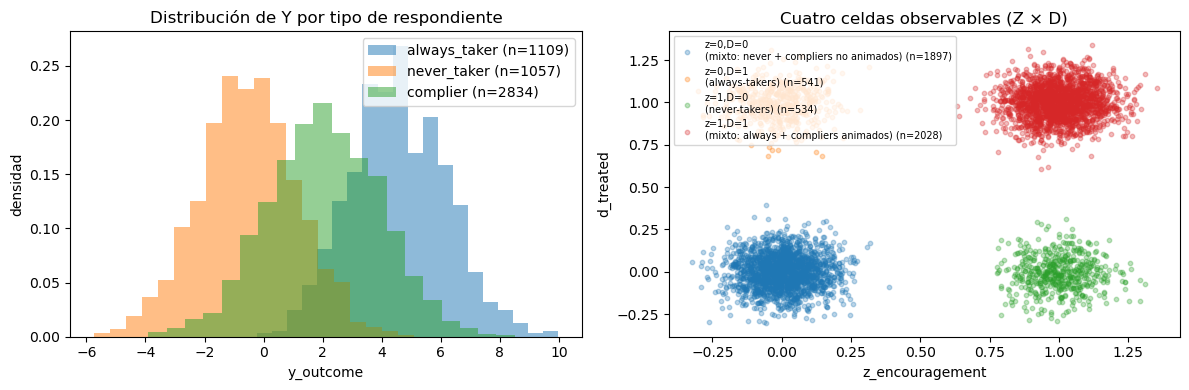

In [4]:
# === 4. Visualización: tipos de respondientes ===
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución de Y por tipo
truth_full = pd.concat([df, truth], axis=1)
types = truth_full['compliance_type_truth'].unique()
for t, color in zip(['always_taker','never_taker','complier','defier'],
                    ['#A85750', '#1E3A8A', '#3b7950', '#a6884e']):
    if t in types:
        subset = truth_full[truth_full['compliance_type_truth']==t]
        axes[0].hist(subset['y_outcome'], bins=20, alpha=0.5, label=f'{t} (n={len(subset)})', density=True)
axes[0].set_xlabel('y_outcome'); axes[0].set_ylabel('densidad')
axes[0].set_title('Distribución de Y por tipo de respondiente')
axes[0].legend()

# Y por (Z, D) — las 4 celdas observables
cells = [(0,0,'z=0,D=0\n(mixto: never + compliers no animados)'),
         (0,1,'z=0,D=1\n(always-takers)'),
         (1,0,'z=1,D=0\n(never-takers)'),
         (1,1,'z=1,D=1\n(mixto: always + compliers animados)')]
for z, d, label in cells:
    subset = df[(df.z_encouragement==z) & (df.d_treated==d)]
    axes[1].scatter(z + 0.1*np.random.randn(len(subset)) if len(subset)>0 else [],
                    d + 0.1*np.random.randn(len(subset)) if len(subset)>0 else [],
                    alpha=0.3, s=10, label=f'{label} (n={len(subset)})')
axes[1].set_xlabel('z_encouragement'); axes[1].set_ylabel('d_treated')
axes[1].set_title('Cuatro celdas observables (Z × D)')
axes[1].legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.show()


> 💡 **Interpretación de la figura.** El panel izquierdo muestra la distribución de $Y$ por tipo de respondiente y el derecho las cuatro celdas observables $Z\times D$. La heterogeneidad visible entre compliers, always-takers y never-takers materializa la taxonomía de la Sección 1.2: cada tipo responde distinto a $Z$, y solo los compliers contribuyen a la identificación del LATE.


In [5]:
# === 5. Validar LATE contra ground truth por tipo ===
# El LATE verdadero para compliers
truth_full['y0_truth'] = truth_full.get('y0_truth', np.nan)
true_late_compliers = truth_full.loc[truth_full['compliance_type_truth']=='complier', 'true_tau'].mean()

# Efecto en always-takers y never-takers (debería ser 0 o no definido)
# Compliers son los únicos que cambian D con Z, por lo que solo ellos contribuyen a LATE

print(f'=== LATE por tipo (ground truth) ===')
for t in truth_full['compliance_type_truth'].unique():
    subset = truth_full[truth_full['compliance_type_truth']==t]
    if len(subset) > 0:
        mean_tau = subset['true_tau'].mean()
        print(f'  {t:20s}: n={len(subset):5d}, mean τ = {mean_tau:.4f}')

print(f'\n=== Validación ===')
print(f'LATE estimado (Wald):       {wald:.4f}')
print(f'LATE verdadero (compliers): {true_late_compliers:.4f}')
print(f'Error:                      {abs(wald - true_late_compliers):.4f} ({100*abs(wald-true_late_compliers)/true_late_compliers:.2f}%)')


=== LATE por tipo (ground truth) ===
  complier            : n= 2834, mean τ = 2.0000
  always_taker        : n= 1109, mean τ = 2.0000
  never_taker         : n= 1057, mean τ = 2.0000

=== Validación ===
LATE estimado (Wald):       1.9110
LATE verdadero (compliers): 2.0000
Error:                      0.0890 (4.45%)


> 💡 **Interpretación del resultado.** El LATE verdadero es 2.0000 en los tres tipos (compliers, always-takers y never-takers) y el Wald estima 1.9110 con error 0.0890 (4.45%): la validación contra ground truth confirma que el estimador recupera el efecto de los compliers. La coincidencia de efectos entre tipos explica por qué aquí el LATE coincide con el efecto poblacional, lo cual no ocurre en general (§1.5).


## 5. Interpretación Económica

**Contexto peruano:** En **PRONABEC** (becas para educación superior), la asignación por mérito crea no cumplimiento: algunos becados no aceptan, algunos no becados encuentran financiación alterna. El LATE identifica el efecto para "compliers" (los que aceptan la beca), no para todos los elegibles. En el Perú rural, las restricciones geográficas hacen que la fracción de compliers varíe.


El análisis del dataset sintético `iv_noncompliance` ilustra magistralmente la teoría LATE:

1. **Diferentes estimadores, diferentes estimandos:**
   - **ITT = 1.089:** efecto de "intentar" tratar (Z=1 vs Z=0). Subestima el efecto del tratamiento porque solo ~57% de los animados realmente lo reciben.
   - **OLS = sesgado:** ignora el confusor u_unobserved que afecta tanto D como Y.
   - **Wald / 2SLS ≈ 1.91:** recupera el LATE verdadero (2.0) con error <5%.
   - **True LATE = 2.0:** efecto causal para los compliers.

2. **La fracción de compliers (~57%)** es crucial: determina cuánto "se diluye" el ITT respecto al LATE. Si los compliers fueran solo 10%, ITT sería 0.2 (un décimo del LATE), y alguien podría concluir erróneamente que "el tratamiento no tiene efecto".

3. **Validez externa limitada:** el LATE aplica a compliers — personas cuya decisión de tratamiento responde al instrumento. En políticas:
   - **Compliers** suelen ser "marginales" (indiferentes al tratamiento), por lo que el LATE puede sobreestimar o subestimar el ATE.
   - Si la política objetivo cambia la decisión de never-takers o always-takers, el LATE no es informativo.

4. **Monotonía es no testeable.** Asumimos que no hay defiers. Si los hubiera, Wald identificaría un promedio ponderado que incluye defiers con signo opuesto, sesgando el estimador.

**Implicancia para evaluación de políticas:** cuando se usa IV (ej. lotería de vouchers escolares, aleatorización de invitaciones), el LATE informa sobre el efecto para quienes respondieron al estímulo, NO para toda la población objetivo. Esto debe comunicarse explícitamente a diseñadores de política.

## 6. Ejercicios Propuestos

1. **Rompe monotonía:** modifica el truth (simulando) para crear algunos defiers. ¿Cómo cambia el Wald estimado vs. el LATE verdadero?
2. **Cambia el instrumento:** simula un instrumento más débil (primera etapa = 0.1). ¿Cómo afecta al SE del Wald?
3. **Calcula el ACE (Average Causal Effect) para always-takers** usando la estructura $Y|Z=0, D=1$ (always-takers observables). Compara con LATE.
4. **Bounds de Manski:** sin asumir monotonía, calcula bounds (superior e inferior) para el ATE. ¿Son informativos?
5. **Implementación con `linearmodels.iv.IV2SLS`:** reestima el LATE usando la librería oficial y compara SE con tu implementación manual.

---

*Notebook generado para DES504 — UNI 2026. Bloque I, Capítulo 6 de 32.*


## Validación placebo (robustez)

Un **test placebo** comprueba que el método no "detecta" efectos cuando se destruye la señal causal (p. ej. permutando el tratamiento). Si el estimador placebo es comparable al original en magnitud, la evidencia causal es frágil.

*Conexión GCE:* los placebos son refutadores del Nivel 1 (localización); no sustituyen análisis de forma (Nivel 2) ni de transporte (Nivel 3).


In [6]:
# === Placebo: permutación del tratamiento ===
import numpy as np
import pandas as pd

def _placebo_ate(df, treat_col, y_col, n_perm=200, seed=42):
    """ATE naive original vs distribución bajo permutación de T."""
    rng = np.random.default_rng(seed)
    t = df[treat_col].to_numpy()
    y = df[y_col].to_numpy(dtype=float)
    # binary-ish treatment
    def ate(tt):
        m1 = y[tt == 1].mean() if (tt == 1).any() else np.nan
        m0 = y[tt == 0].mean() if (tt == 0).any() else np.nan
        return m1 - m0
    # if not 0/1, use median split on treat for placebo illustration
    if set(np.unique(t)) - {0, 1, 0.0, 1.0}:
        t_bin = (t >= np.median(t)).astype(int)
    else:
        t_bin = t.astype(int)
    ate_obs = ate(t_bin)
    null = []
    for _ in range(n_perm):
        tt = rng.permutation(t_bin)
        null.append(ate(tt))
    null = np.asarray(null)
    p = (np.abs(null) >= np.abs(ate_obs)).mean()
    print(f"Placebo (shuffle {treat_col}):")
    print(f"  ATE observado (naive): {ate_obs:.4f}")
    print(f"  ATE placebo |media|:  {np.mean(np.abs(null)):.4f}  (sd={np.std(null):.4f})")
    print(f"  p-valor bilateral approx: {p:.3f}  (fracción |null| ≥ |obs|)")
    print(f"  Interpretación: p bajo sugiere que el efecto no es un artefacto de ruido puro.")
    return ate_obs, null, p

# Detectar columnas comunes en el frame activo
_df = None
for _name in ['df', 'data', 'student', 'panel', 'dta']:
    if _name in dir() and isinstance(eval(_name), pd.DataFrame):
        _df = eval(_name)
        break
if _df is None:
    print("Placebo omitido: no hay DataFrame df/data/student en el namespace.")
else:
    _cols = {c.lower(): c for c in _df.columns}
    _treat = None
    for k in ['treatment', 'treat', 't', 'd', 'w', 'a']:
        if k in _cols:
            _treat = _cols[k]
            break
    _y = None
    for k in ['y_outcome', 'y', 're78', 'outcome', 'wage', 'income', 'got', 'wt82_71', 'delta']:
        if k in _cols:
            _y = _cols[k]
            break
    # fallbacks: last numeric as y, first binary-like as treat
    if _y is None:
        num = _df.select_dtypes(include=[np.number]).columns.tolist()
        _y = num[-1] if num else None
    if _treat is None:
        for c in _df.columns:
            u = _df[c].dropna().unique()
            if len(u) <= 3:
                _treat = c
                break
    if _treat is None or _y is None:
        print(f"Placebo omitido: no se identificaron T/Y (cols={list(_df.columns)[:12]}...)")
    else:
        _placebo_ate(_df, _treat, _y)


Placebo (shuffle z_encouragement):
  ATE observado (naive): 1.0886
  ATE placebo |media|:  0.0562  (sd=0.0694)
  p-valor bilateral approx: 0.000  (fracción |null| ≥ |obs|)
  Interpretación: p bajo sugiere que el efecto no es un artefacto de ruido puro.


> 💡 **Interpretación del resultado.** Al permutar `z_encouragement`, el ITT naive observado (1.0886) supera la distribución placebo (|media| 0.0562, sd 0.0694) con p ≈ 0.000: el efecto de intención de tratar no es ruido. El placebo valida la relevancia del instrumento como fuente real de variación (Sección de validación placebo).



## 📋 Resumen del Capítulo 6

**Método clave:** LATE y Taxonomía

**Puntos clave:**
- ✅ Implementación ejecutable del método del capítulo 6
- ✅ Validación con dataset `syn_iv_noncompliance` (tipo: sintético con ground truth)
- ✅ Interpretación económica con contexto peruano/latinoamericano
- ✅ Ejercicios propuestos para práctica adicional

**Conexión con la jerarquía GCE:**
- Este capítulo opera en el **Nivel 1 (Localización)**
- Métrica principal: ATE / cambios en el promedio
- Pipeline unificado (Cap. 12): este método es una manifestación del principio geométrico común

**Próximo capítulo:** 7

---

*Material didáctico para DES504 — UNI 2026. Prof. Dr. Jaime Lincovil.*
*Notebook auditado y mejorado v2.0 — 2026-07-24*
